In [1]:
#Inicialização de dependências das bibliotecas:
import subprocess

def instalar_dependencias():
    subprocess.call(['pip','install','-r','requirements.txt'])

if __name__ == "__main__":
    instalar_dependencias()
    print('Dependências instaladas')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Importando o modulo para processamento das variáveis categóricas em vetores com 0 e 1 para n categorias
from sklearn.preprocessing import OneHotEncoder

Dependências instaladas


In [2]:
dataset = pd.read_csv('NHNES.csv')

In [3]:
dataset.columns

Index(['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060',
       'DPQ070', 'DPQ080', 'DPQ090', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1',
       'DMDEDUC', 'INDFMINC', 'PAG_MINW', 'ADHERENCE', 'HEI2015C1_TOTALVEG',
       'HEI2015C2_GREEN_AND_BEAN', 'HEI2015C3_TOTALFRUIT',
       'HEI2015C4_WHOLEFRUIT', 'HEI2015C5_WHOLEGRAIN', 'HEI2015C6_TOTALDAIRY',
       'HEI2015C7_TOTPROT', 'HEI2015C8_SEAPLANT_PROT', 'HEI2015C9_FATTYACID',
       'HEI2015C10_SODIUM', 'HEI2015C11_REFINEDGRAIN', 'HEI2015C12_SFAT',
       'HEI2015C13_ADDSUG', 'HEI2015_TOTAL_SCORE', 'PHQ9', 'PHQ9_CLASS',
       'RIDAGEYR_CLASS'],
      dtype='object')

In [4]:
df = dataset[['SEQN','RIAGENDR', 'RIDRETH1','DMDEDUC', 'INDFMINC','PHQ9']]

df.head()

,SEQN,RIAGENDR,RIDRETH1,DMDEDUC,INDFMINC,PHQ9
0,31131,2,4,4,11.0,0.0
1,31132,1,3,5,11.0,0.0
2,31134,1,3,3,12.0,0.0
3,31139,2,2,3,11.0,4.0
4,31143,1,3,4,11.0,6.0


In [5]:
print(df.isnull().sum()) #Verificando a existência de nulos antes da aplicação dos tratamentos e modelo

SEQN        0
RIAGENDR    0
RIDRETH1    0
DMDEDUC     0
INDFMINC    0
PHQ9        0
dtype: int64


Vamos utilizar, primeiramente, um modelo baseado em variáveis sobre a pessoa (renda, gênero, idade, etc) e avaliar a performance desse modelo. 

Inicialmente vamos aplicar uma consideração que pessoas com sintomas leves ou graves serão considerados classe 1 e sem sintomas como classe 0

Nosso intuito é entender se, dado uma série de características sobre a pessoa, teremos como supor a incidência de um caso depressivo na mesma?

In [6]:
def mapa_valores(x):
    if x < 5:
        return 0
    else:
        return 1
    
df['PHQ9_CLASS'] = df['PHQ9'].map(lambda x: mapa_valores(x))

C:\Users\albino\AppData\Local\Temp\ipykernel_3992\1084600746.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PHQ9_CLASS'] = df['PHQ9'].map(lambda x: mapa_valores(x))


In [7]:
df.groupby('PHQ9_CLASS')['SEQN'].count()

PHQ9_CLASS
0    3706
1     996
Name: SEQN, dtype: int64

<BarContainer object of 2 artists>

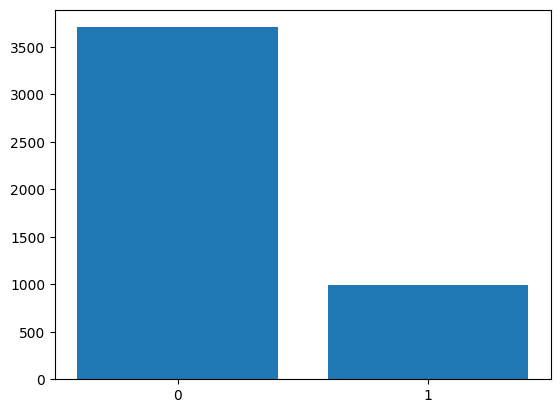

In [8]:
plt.bar(['0','1'],df.groupby('PHQ9_CLASS')['SEQN'].count())

In [9]:
#Alguns parâmetros importantes:

#Handle_unknown -> O que fazer com dados faltantes, nesse caso não temos esse problema
#sparse_outpu -> não queremos uma matriz esparsa
#set_output(transform = 'pandas') -> queremos o resultado como um dataframe

ohe = OneHotEncoder(
    handle_unknown='ignore'
    ,sparse_output=False
).set_output(transform='pandas')

In [10]:
df[['RIAGENDR', 'RIDRETH1', 'DMDEDUC', 'INDFMINC']]

,RIAGENDR,RIDRETH1,DMDEDUC,INDFMINC
0,2,4,4,11.0
1,1,3,5,11.0
2,1,3,3,12.0
3,2,2,3,11.0
4,1,3,4,11.0
...,...,...,...,...
4697,2,5,2,3.0
4698,2,1,1,8.0
4699,1,4,4,2.0
4700,1,3,4,7.0


In [11]:
ohetransform = ohe.fit_transform(df[['RIAGENDR', 'RIDRETH1', 'DMDEDUC', 'INDFMINC']])

In [12]:
ohetransform.columns

Index(['RIAGENDR_1', 'RIAGENDR_2', 'RIDRETH1_1', 'RIDRETH1_2', 'RIDRETH1_3',
       'RIDRETH1_4', 'RIDRETH1_5', 'DMDEDUC_1', 'DMDEDUC_2', 'DMDEDUC_3',
       'DMDEDUC_4', 'DMDEDUC_5', 'DMDEDUC_9', 'INDFMINC_1.0', 'INDFMINC_2.0',
       'INDFMINC_3.0', 'INDFMINC_4.0', 'INDFMINC_5.0', 'INDFMINC_6.0',
       'INDFMINC_7.0', 'INDFMINC_8.0', 'INDFMINC_9.0', 'INDFMINC_10.0',
       'INDFMINC_11.0', 'INDFMINC_12.0', 'INDFMINC_13.0', 'INDFMINC_77.0',
       'INDFMINC_99.0'],
      dtype='object')

In [13]:
print(ohetransform.isna().sum()) #Verificando a existência de nulos antes da aplicação dos tratamentos e modelo

RIAGENDR_1       0
RIAGENDR_2       0
RIDRETH1_1       0
RIDRETH1_2       0
RIDRETH1_3       0
RIDRETH1_4       0
RIDRETH1_5       0
DMDEDUC_1        0
DMDEDUC_2        0
DMDEDUC_3        0
DMDEDUC_4        0
DMDEDUC_5        0
DMDEDUC_9        0
INDFMINC_1.0     0
INDFMINC_2.0     0
INDFMINC_3.0     0
INDFMINC_4.0     0
INDFMINC_5.0     0
INDFMINC_6.0     0
INDFMINC_7.0     0
INDFMINC_8.0     0
INDFMINC_9.0     0
INDFMINC_10.0    0
INDFMINC_11.0    0
INDFMINC_12.0    0
INDFMINC_13.0    0
INDFMINC_77.0    0
INDFMINC_99.0    0
dtype: int64


In [14]:
ohetransform = ohetransform.reset_index(names=['SEQN'])

base = ohetransform.join(df[['SEQN','PHQ9_CLASS']], lsuffix='SEQN', rsuffix='SEQN', how='inner')


In [15]:
#dataset_treino -> 
# Variáveis categóricas de input -> 'RIAGENDR', 'RIDAGEYR_CLASS', 'RIDRETH1', 'DMDEDUC', 'INDFMINC'
# Variável output de interesse ->  'PHQ9_CLASS'

X = base[['RIAGENDR_1', 'RIAGENDR_2','RIDRETH1_1', 'RIDRETH1_2', 'RIDRETH1_3', 'RIDRETH1_4', 'RIDRETH1_5',
       'DMDEDUC_1', 'DMDEDUC_2', 'DMDEDUC_3', 'DMDEDUC_4', 'DMDEDUC_5',
       'DMDEDUC_9', 'INDFMINC_1.0', 'INDFMINC_2.0', 'INDFMINC_3.0',
       'INDFMINC_4.0', 'INDFMINC_5.0', 'INDFMINC_6.0', 'INDFMINC_7.0',
       'INDFMINC_8.0', 'INDFMINC_9.0', 'INDFMINC_10.0', 'INDFMINC_11.0',
       'INDFMINC_12.0', 'INDFMINC_13.0', 'INDFMINC_77.0', 'INDFMINC_99.0']]
Y = base[['PHQ9_CLASS']]

Aqui vale a ressalva que nossos valores estão bastante desbalanceados!

Como podemos lidar com isso?

- Existem métodos que podemos aplicar para equilibrar nossas amostras de treino e teste. Porém nosso primeiro teste será considerando que nossa amostra está balanceada e pode ser utilizada dentro de um modelo de regressão logística

Nosso primeiro passo será dividir os dados em amostras de <b>Treino</b> e <b>Teste</b> 

PHQ9_CLASS
0    2600
1     691
Name: index, dtype: int64


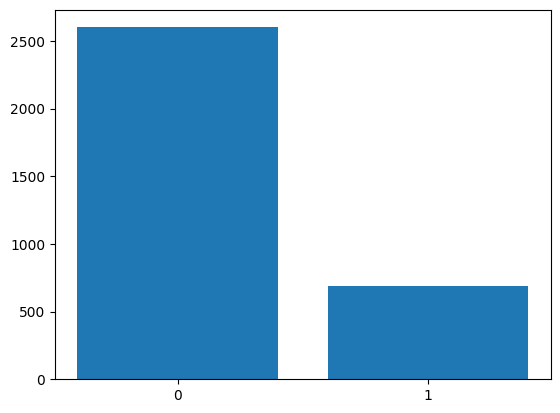

In [16]:

x_treino, x_teste, y_treino, y_teste = train_test_split( X , Y, test_size = 0.3, random_state = 123456)

y_treino_grafico = y_treino.reset_index()

plt.bar(['0','1'],y_treino_grafico.groupby('PHQ9_CLASS')['index'].count()) #Muito desbalanceado!    
print(y_treino_grafico.groupby('PHQ9_CLASS')['index'].count())

In [17]:

classifier = LogisticRegression(random_state=42)

classifier.fit(x_treino, y_treino)

C:\Users\albino\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(random_state=42)

In [18]:
y_predito = classifier.predict(x_teste)

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_teste, y_predito, labels = ['0', '1'])


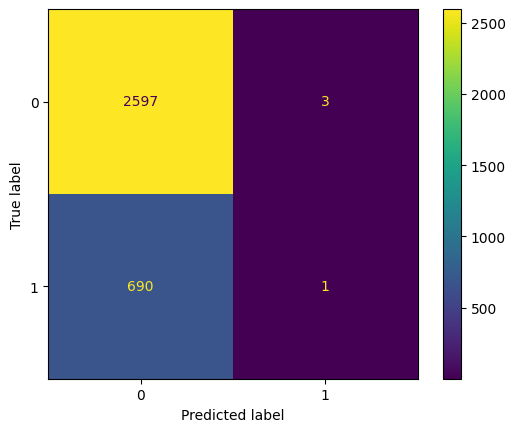

In [20]:
ConfusionMatrixDisplay.from_estimator(classifier, x_treino, y_treino)

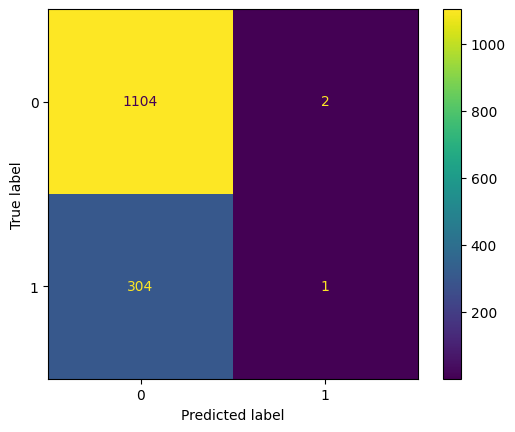

In [21]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_predito)

Nosso modelo performou muito mal, não conseguiu capturar os parâmetros atrelados com o sintoma para a classe 1.

Vamos ter que abordar alguns outros pontos dentro da nossa análise: Primeiro, tentar realizar uma amostra mais balanceada de dados.

In [73]:
classe_0 = base[base['PHQ9_CLASS'] == 0].count()
classe_1 = base[base['PHQ9_CLASS'] == 1].count()


total = classe_0['SEQNSEQN'][0] + classe_1['SEQNSEQN'][0]


C:\Users\albino\AppData\Local\Temp\ipykernel_3992\244492585.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total = classe_0['SEQNSEQN'][0] + classe_1['SEQNSEQN'][0]


In [76]:
#No dataset completo temos uma proporção de 4 para 1 aproximadamente. Temos que tratar esse desbalanceamento no input do modelo logístico 
#ou corremos o risco, como visto acima, de não conseguir capturar o comportamento de uma classe

print(f'Classe 0: {classe_0['SEQNSEQN'][0]*100/total:.0f} | Classe 1:  {classe_1['SEQNSEQN'][0]*100/total:.0f}') 



Classe 0: 79 | Classe 1:  21


C:\Users\albino\AppData\Local\Temp\ipykernel_3992\2394009477.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Classe 0: {classe_0['SEQNSEQN'][0]*100/total:.0f} | Classe 1:  {classe_1['SEQNSEQN'][0]*100/total:.0f}')


In [ ]:
#Racional de cálculo
#k classes desbalanceadas
#Achar qual classe k_i tem menos valores e quantos são
#Sortear aleatoriamente, dentro dessa série, N valores que façam com que Nk_i (número de registros em k_i) seja igual a Nk_j (registros em k_j)

In [130]:
def under_sampler(dataset, target):
    #dataset -> conjunto total de dados a sofrer undersample
    #seed -> número para gerador de número aleatório (opcional)
    #target -> variáveis para serem aferidas (k_i)
    #seed =
    classes = dataset[target].unique()
    sample = [dataset[dataset['target'] == classes[i]].count() for i in len(classes)]
    return sample


In [125]:
d = {'target': ['1','0','1'], 'name': ['ana','luis','luiz']}

d = pd.DataFrame(data=d)

In [1]:
print('Hello World')

Hello World


In [126]:
classe_1 = d['target'][d['target'] == '1'].value_counts()
classe_0 = d['target'][d['target'] == '0'].value_counts()

print(classe_1, classe_0)

target
1    2
Name: count, dtype: int64 target
0    1
Name: count, dtype: int64


In [148]:
classes = d['target'].unique()

print(classes)
sample = d.groupby('target').count()
sample

['1' '0']


,name
target,
0,1
1,2


In [135]:
for i in range(len(classes)):
    print(i)

0
1
